## Tarea 10: Clasificacion de Texto
## Nombre: Sergio Trejo
## Matricula: 261539
## Materia: Procesamiento de Lenguaje Natural_A_Presencial_260206

Clasificación de texto

Actividad
*   Utilizar el dataset IMDB Reviews.csv, el cual contiene dos clases en la columna ‘sentiment’: 1 indica un sentiment positivo y 0 uno negativo. NOTA: Los comentarios están en inglés.
*   Realizar el preprocesamiento adecuado con respecto a lo que identifiques en el dataset.
*   Realizar un análisis exploratorio de datos.
*   Utilizar Bag of Words y TF-IDF para transformar los comentarios que están en la columna ‘Review’ a vectores.
*   Utiliza una partición (train_test_split) 80-20 para los conjuntos train y test.
*   Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression
*   Mostrar la matriz de confusión.
*   Aplicar las métricas Precision, Recall, F1-Score (por cada una de las clases), Accuracy y AUC-ROC.



Genera dos tablas como la siguiente, una utilizando Bag of Word y la otra utilizando TF-IDF.

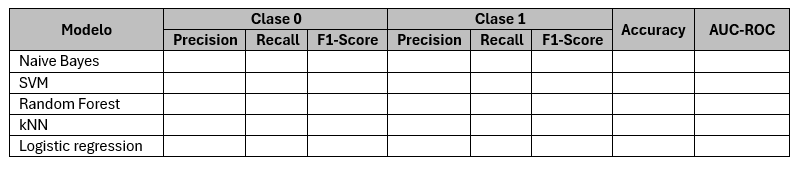

Analiza y compara los resultados para responder lo siguiente:
•	¿Cuál fue el mejor modelo en cada una de las tablas? Justifica tus respuestas en base a las métricas obtenidas.
•	¿En qué estrategia funcionaron mejor los algoritmos de clasificación, en Bag of Words o en TF-IDF?



In [31]:
#Importacion de librerias

import string
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /home/sergioai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sergioai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Procesamiento de Texto

In [32]:
#Lectura del dataset
def readDataset(filename):
    df = pd.read_csv(filename)
    print(df.head())
    print(df.shape)
    print(df.isnull().sum())
    print(df['sentimiento'].value_counts())
    return df
df = readDataset('IMDB Reviews.csv')

#Procesamiento de texto
port_stem = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [port_stem.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

                                              review  sentimiento
0  One of the other reviewers has mentioned that ...            1
1  A wonderful little production. <br /><br />The...            1
2  I thought this was a wonderful way to spend ti...            1
3  Basically there's a family where a little boy ...            0
4  Petter Mattei's "Love in the Time of Money" is...            1
(50000, 2)
review         0
sentimiento    0
dtype: int64
sentimiento
1    25000
0    25000
Name: count, dtype: int64


## Analisis Exploratorio de Datos


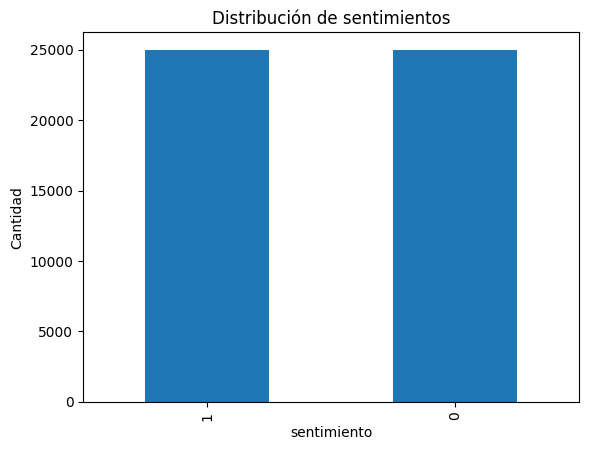

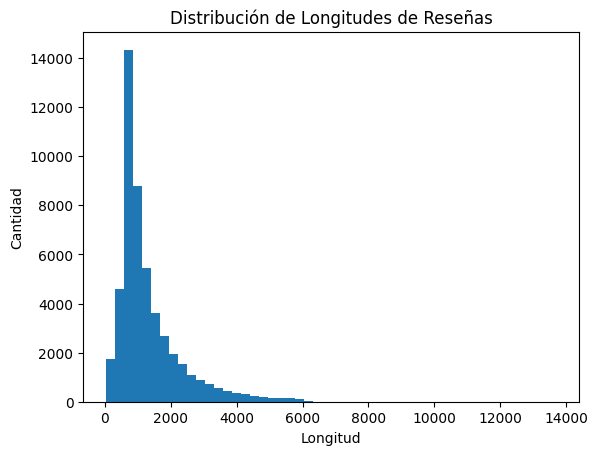

In [33]:
def EDA(df):
    df['sentimiento'].value_counts().plot(kind='bar')
    plt.title('Distribución de sentimientos')
    plt.xlabel('sentimiento')
    plt.ylabel('Cantidad')
    plt.show()

    df['length'] = df['review'].apply(len)
    df['length'].plot(kind='hist', bins=50)
    plt.title('Distribución de Longitudes de Reseñas')
    plt.xlabel('Longitud')
    plt.ylabel('Cantidad')
    plt.show()

EDA(df)

## Aplicar Limpieza de los Datos y Division de Datos

In [34]:
df['Cleaned_Review'] = df['review'].apply(clean_text)

X = df['Cleaned_Review'].values
y = df['sentimiento'].values

#Division del dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Vectorizacion con Bag of Words y TF-IDF

In [35]:
#Vectorización Bag of Words
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

#Vectorización TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

## Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression

In [36]:
#Entrenamiento de modelos
models = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SGDClassifier(),
    'Random Forest': RandomForestClassifier(),
    'kNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=200)
}

## Mostrar la matriz de confusión y evaluacion

RESULTADOS CON BAG OF WORDS

Modelo: MultinomialNB
Accuracy: 0.8494
AUC: 0.8494391998809208
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000





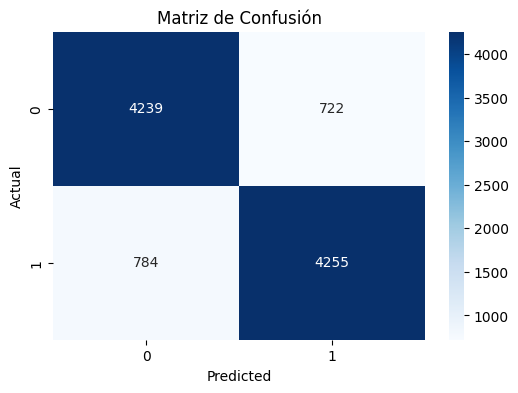

Modelo: SGDClassifier
Accuracy: 0.8655
AUC: 0.8658046155528102
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4961
           1       0.90      0.83      0.86      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000





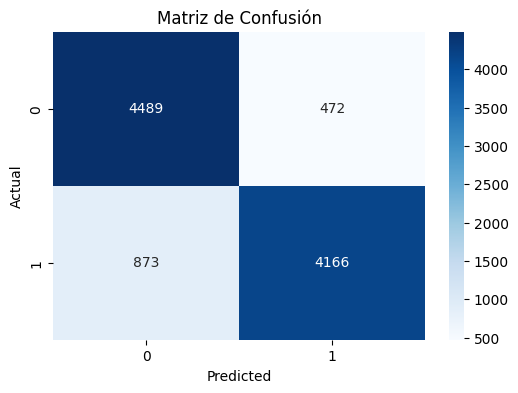

Modelo: RandomForestClassifier
Accuracy: 0.8461
AUC: 0.8461413392390793
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000





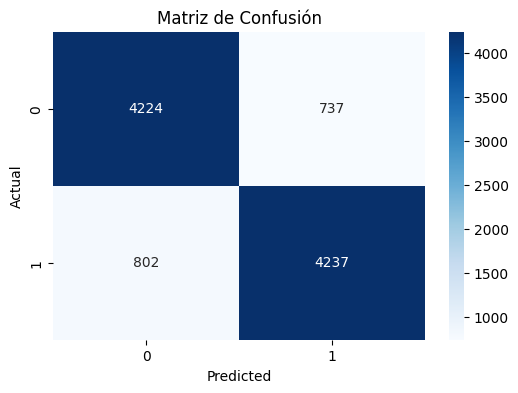

Modelo: KNeighborsClassifier
Accuracy: 0.6303
AUC: 0.630694831473547
              precision    recall  f1-score   support

           0       0.61      0.68      0.65      4961
           1       0.65      0.58      0.61      5039

    accuracy                           0.63     10000
   macro avg       0.63      0.63      0.63     10000
weighted avg       0.63      0.63      0.63     10000





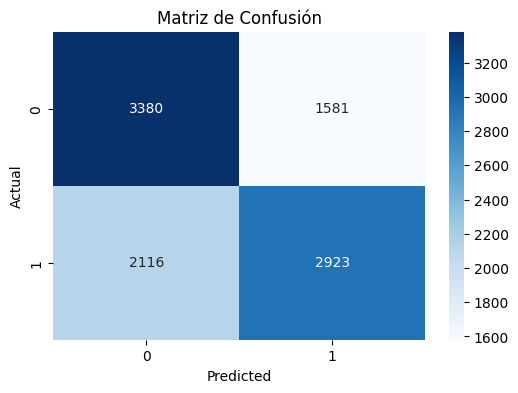

Modelo: LogisticRegression
Accuracy: 0.8709
AUC: 0.8708367617085824
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4961
           1       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000





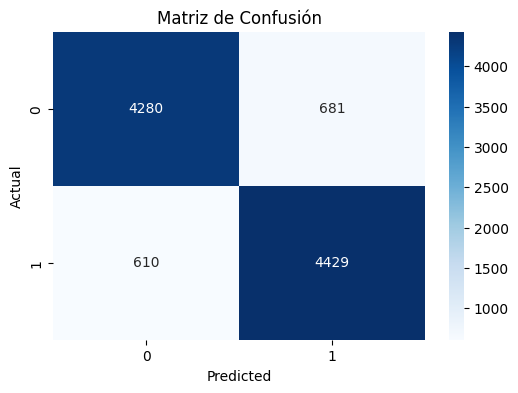

RESULTADOS CON TF-IDF

Modelo: MultinomialNB
Accuracy: 0.8518
AUC: 0.8517488604006669
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000





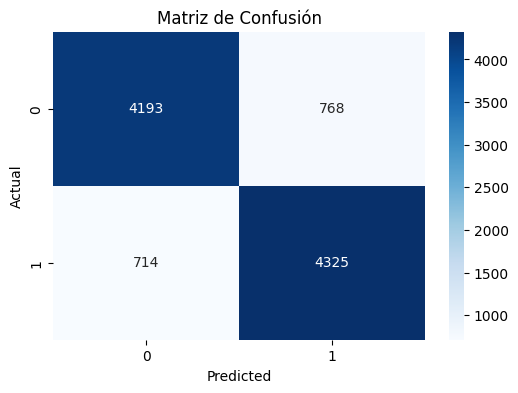

Modelo: SGDClassifier
Accuracy: 0.8846
AUC: 0.8844494499045321
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.87      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000





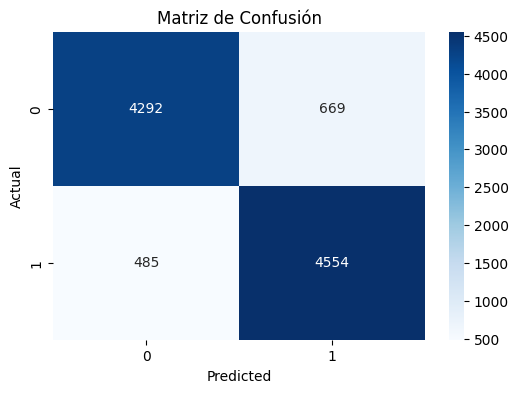

Modelo: RandomForestClassifier
Accuracy: 0.8449
AUC: 0.8449428263215534
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000





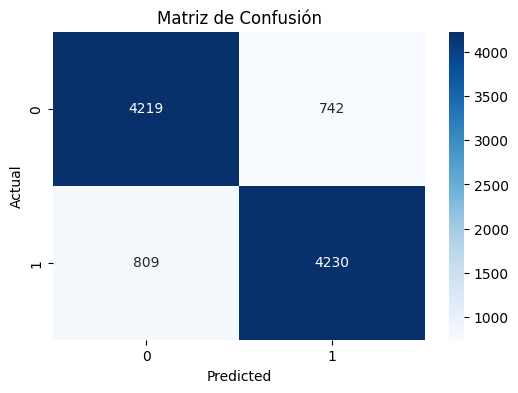

Modelo: KNeighborsClassifier
Accuracy: 0.751
AUC: 0.7506525497011239
              precision    recall  f1-score   support

           0       0.77      0.71      0.74      4961
           1       0.73      0.80      0.76      5039

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000





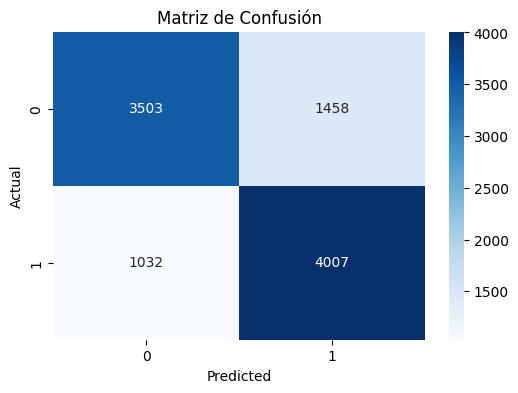

Modelo: LogisticRegression
Accuracy: 0.8856
AUC: 0.8854760323618089
              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000





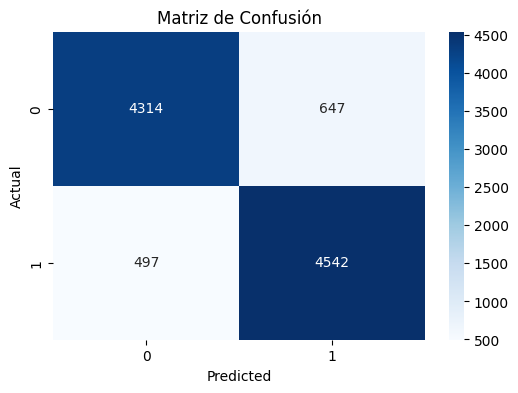

In [37]:
def evaluate_model(model, X_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Modelo:", model.__class__.__name__)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("\n")
    #Matriz de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


print("RESULTADOS CON BAG OF WORDS\n")

for name, model in models.items():
    evaluate_model(model, X_train_bow, X_test_bow)

print("RESULTADOS CON TF-IDF\n")

for name, model in models.items():
    evaluate_model(model, X_train_tfidf, X_test_tfidf)